# Задача: создание модели нейронной сети для определения тональности комментариев

### Подключение первичных необходимых библиотек

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [45]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install pymorphy3

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Загрузка комментариев и работа с датасетом

In [49]:
file_14k = r"C:\Users\MSi\Downloads\Telegram Desktop\labeled.xlsx"
file_250k = r"C:\Users\MSi\Downloads\Telegram Desktop\dataset.txt"

with open(file_14k, encoding = 'utf-8') as file:
    print("Успех")
with open(file_250k, encoding = 'utf-8') as file:
    print("Успех")

df = pd.read_excel(file_14k, skiprows=1)

Успех
Успех


In [50]:
df

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comment  14412 non-null  object 
 1   toxic    14412 non-null  float64
dtypes: float64(1), object(1)
memory usage: 225.3+ KB


In [52]:
df['toxic'] = df['toxic'].astype(int)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  14412 non-null  object
 1   toxic    14412 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 225.3+ KB


In [54]:
df.toxic.value_counts()

toxic
0    9586
1    4826
Name: count, dtype: int64

In [55]:
df.comment[14409]

'Посмотрел Утомленных солнцем 2. И оказалось, что это хороший фильм, такая высокобюджетная артхаусятина, к которой могут быть претензии только потому, что спиздили-распилили и вообще ТАК НЕ БЫВАЕТ. Ну нахуй этих критиков. Обзоры длиннее фильмов, петросянство хуже рашкокомедий, ебанутая ненависть и доебки по мелочам.\n'

In [56]:
df.comment[14411]

'До сих пор пересматриваю его видео. Орамбо кстати на своем канале пилит похожий контент, но качеством похуже, там же и Шуран не редко светится, храню хрупкую надежду что когда-то он вернется, такая годнота ведь.\n'

In [57]:
def create_df():
    data_list = []
    with open(file_250k, 'r', encoding = 'utf-8') as file:
        for idx, line in enumerate(file):
            parts = line.split(maxsplit=1)
            labels = parts[0].replace('__label__','')
            text = parts[1].strip()
            mask = [1 if "NORMAL" in labels else 0,
                    1 if "INSULT" in labels else 0,
                    1 if "THREAT" in labels else 0,
                    1 if "OBSCENITY" in labels else 0]
            data_list.append((text, *mask))
        return pd.DataFrame(data_list, columns=["comment", "normal", "insult", "threat", "obscenity"])

In [58]:
df2 = create_df()

In [59]:
df2

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [60]:
df2.normal.value_counts()

normal
1    203685
0     44605
Name: count, dtype: int64

In [61]:
df2.comment[1]

'я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.'

### Очистка данных

In [62]:
df2

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   comment    248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 9.5+ MB


In [64]:
# Перевод комментов в строчный вид
df2['comment'] = df2['comment'].str.lower()
# Удаление лишних пробелов по бокам и символы переноса строки
df2['comment'] = df2['comment'].str.strip()

In [65]:
df2

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


In [66]:
df2.comment[1]

'я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.'

In [67]:
import re

def clean_text(text):
    # Удаление URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Удаление символов отлчных от ASCII
    text = re.sub('[^a-zA-Zа-яА-ЯёЁ]+', ' ', text)
    # Удаление пунктуации и спецсимволов
    text = re.sub(r'[^\w\s]', ' ', text)
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [68]:
df2['comment'] = df2['comment'].apply(clean_text)

In [69]:
df2.comment[248285]

'правильно всё по пять'

### Токенизация, удаление стоп-слов, лемматизация

In [73]:
import nltk
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MSi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MSi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MSi\AppData\Roaming\nltk_data...


True

In [74]:
morph = MorphAnalyzer()
my_stop_words = ["такой", "это", "всё", "весь"]
stop_words = set(stopwords.words('russian'))
stop_words.update(my_stop_words)

def full_preprocess(text):  
    # Токенизация
    tokens = nltk.word_tokenize(text.lower())
    # Очистка
    words = [t.replace('ё', 'е') for t in tokens if t.isalpha()]
    # Лемматизация
    lemmas = [morph.parse(w)[0].normal_form for w in words]
    # Удаление стоп-слов
    filtered_lemmas = [l for l in lemmas if l not in stop_words]
    
    return filtered_lemmas

In [75]:
%%time
df2['comment'] = df2['comment'].apply(full_preprocess)

CPU times: total: 4min 50s
Wall time: 4min 59s


In [76]:
df2

,comment,normal,insult,threat,obscenity
0,"[скотина, сказать]",0,1,0,0
1,"[сегодня, проезжать, рабочий, дом, снитенко, г...",1,0,0,0
2,"[очередной, лохотрон, придумывать, очередной, ...",1,0,0,0
3,"[ретро, дежавю, сложно, понять, чужое, сердце,...",1,0,0,0
4,"[статус, агрогородок, получить]",1,0,0,0
...,...,...,...,...,...
248285,"[правильно, пять]",1,0,0,0
248286,"[ебанный, нуба, заходить, сервер, ник, creepro...",0,1,0,0
248287,"[наверное, рекорд, год, училище, коренной, зуб...",1,0,0,0
248288,"[спасибо, большой]",1,0,0,0


In [77]:
df2.comment[248275]

['тошнить', 'протестант', 'безельник', 'олигофрен', 'тьфу']

### Визуальный анализ

C:\Users\MSi\AppData\Local\Temp\ipykernel_3828\314579830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='magma')


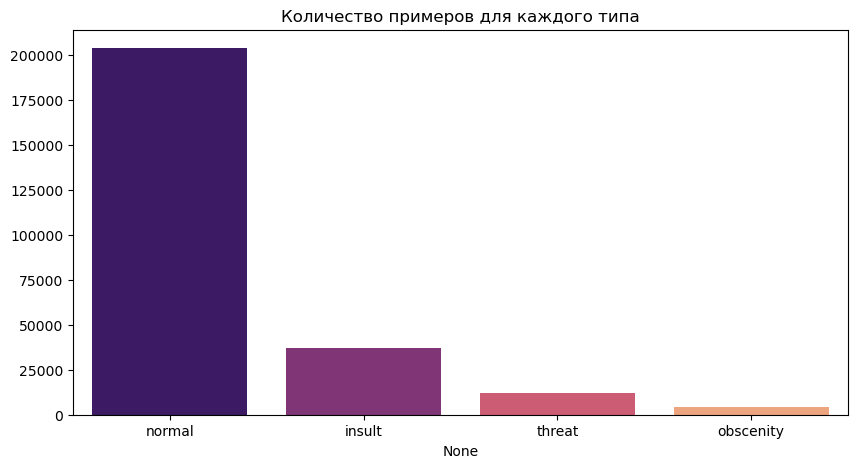

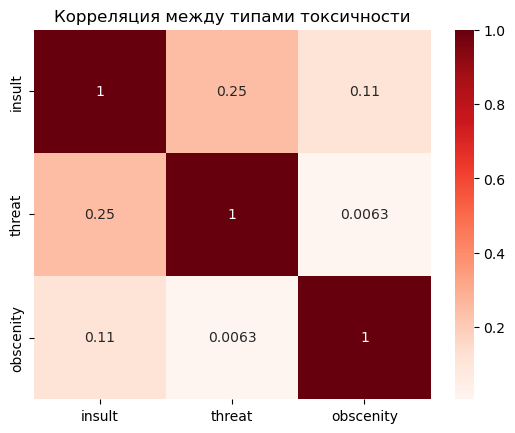

In [78]:
class_counts = df2[['normal', 'insult', 'threat', 'obscenity']].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='magma')
plt.title('Количество примеров для каждого типа')
plt.show()

sns.heatmap(df2[['insult', 'threat', 'obscenity']].corr(), annot=True, cmap='Reds')
plt.title('Корреляция между типами токсичности')
plt.show()

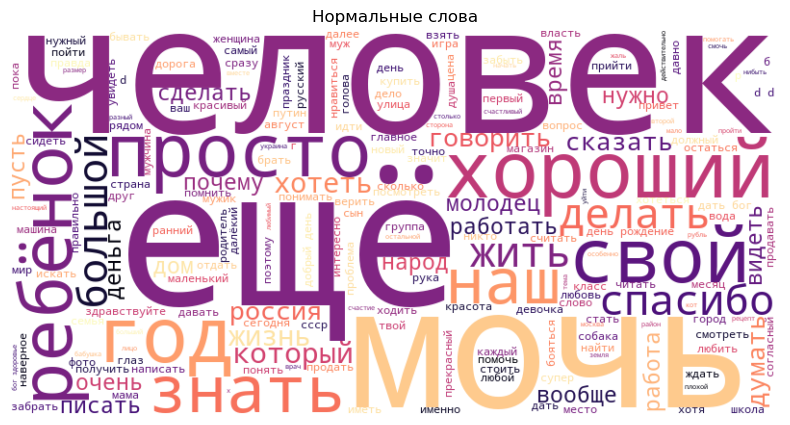

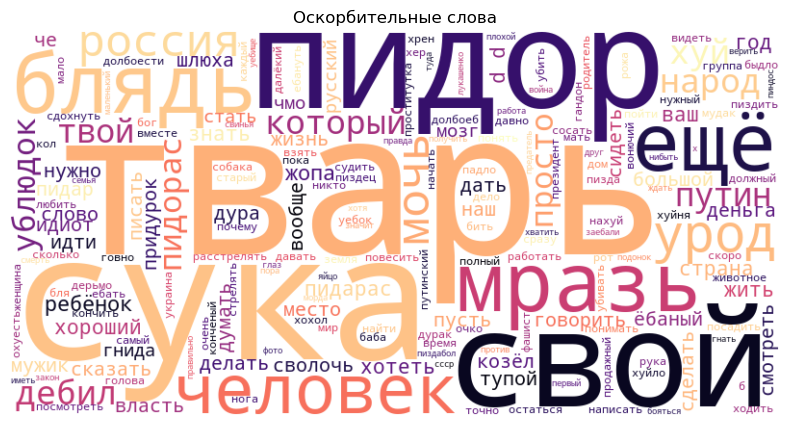

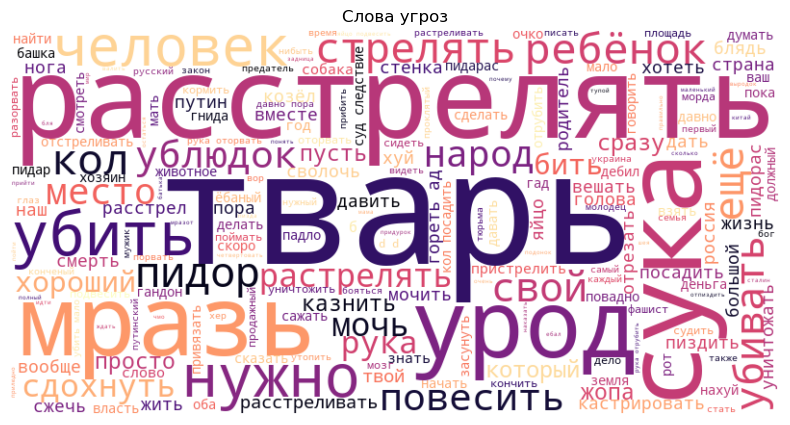

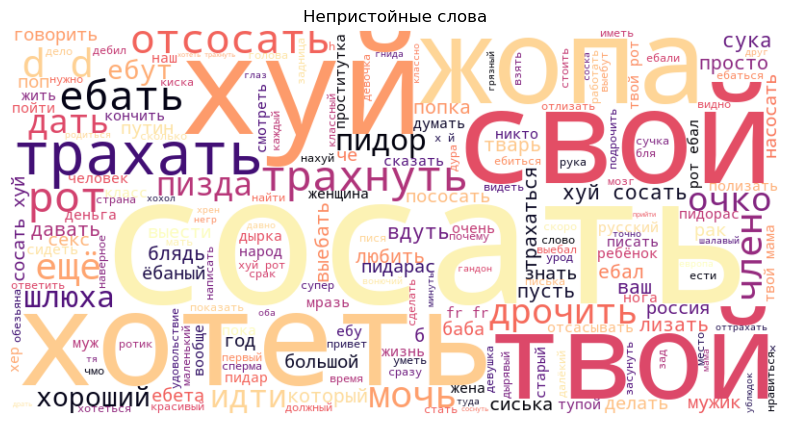

In [79]:
from wordcloud import WordCloud

def show_wordcloud(data: list, title):
    data = [" ".join(doc) for doc in data]
    text = " ".join(data)
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap='magma').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

show_wordcloud(df2[df2['normal'] == 1]['comment'], "Нормальные слова")
show_wordcloud(df2[df2['insult'] == 1]['comment'], "Оскорбительные слова")
show_wordcloud(df2[df2['threat'] == 1]['comment'], "Слова угроз")
show_wordcloud(df2[df2['obscenity'] == 1]['comment'], "Непристойные слова")

In [92]:
file_path = r"C:\Users\MSi\Downloads\Telegram Desktop\dataset.csv"

# Загружаем файл с правильным разделителем (; работает)
df_raw = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')

print("Исходные данные:")
print(f"Размер: {df_raw.shape}")
print(f"Колонки: {df_raw.columns.tolist()}")
print("\nПервые 5 строк:")
print(df_raw.head())

Исходные данные:
Размер: (248290, 1)
Колонки: ['Column1']

Первые 5 строк:
                                             Column1
0               __label__INSULT скотина! что сказать
1  __label__NORMAL я сегодня проезжала по рабочей...
2  __label__NORMAL очередной лохотрон. зачем прид...
3  __label__NORMAL ретро дежавю ... сложно понять...
4  __label__NORMAL а когда мы статус агрогородка ...


In [97]:
def extract_label_comment(text):
    """Извлекает метку и комментарий из строки"""
    if pd.isna(text):
        return pd.Series(['', ''])
    
    text = str(text)
    # Ищем метку вида __label__XXXX
    import re
    match = re.match(r'(__label__[A-Z]+)\s+(.*)', text)
    
    if match:
        label = match.group(1).replace('__label__', '')  # убираем __label__
        comment = match.group(2)
        return pd.Series([label, comment])
    else:
        return pd.Series(['', text])

# Применяем функцию к данным
df2 = df_raw['Column1'].apply(extract_label_comment)
df2.columns = ['label', 'comment']

print("\n" + "="*50)
print("Обработанные данные:")
print(f"Размер: {df2.shape}")
print(f"Колонки: {df2.columns.tolist()}")
print("\nПервые 10 строк:")
print(df2.head(10))

# Проверяем распределение меток
print("Распределение меток:")
print(df2['label'].value_counts())
print("\nУникальные метки:", df2['label'].unique())

# Создаем маску для нормальных комментариев (только NORMAL)
only_normal = df2['label'] == 'NORMAL'

# Разделяем датафреймы
df_normal = df2[only_normal].copy()
df_toxic = df2[~only_normal].copy()

print(f"\nНормальные комментарии: {len(df_normal)}")
print(f"Токсичные комментарии: {len(df_toxic)}")
print(f"Всего: {len(df_normal) + len(df_toxic)}")

# Проверяем распределение в токсичных
print("\nРаспределение токсичных комментариев:")
print(df_toxic['label'].value_counts())


Обработанные данные:
Размер: (248290, 2)
Колонки: ['label', 'comment']

Первые 10 строк:
    label                                            comment
0  INSULT                               скотина! что сказать
1  NORMAL  я сегодня проезжала по рабочей и между домами ...
2  NORMAL  очередной лохотрон. зачем придумывать очередно...
3  NORMAL  ретро дежавю ... сложно понять чужое сердце , ...
4  NORMAL            а когда мы статус агрогородка получили?
5  NORMAL  2 августа поздно вечером нашли вот такую потер...
6  NORMAL        вчера надыбала новые стикеры #u2a94ec7fabs#
7          __label__INSULT,__label__THREAT заколоть этого...
8  NORMAL  а еще на стоянке никто не проверяет безопаснос...
9  NORMAL  красота..!! если есть, что показать??!! почему...
Распределение меток:
label
NORMAL       203685
INSULT        28567
               8333
THREAT         5460
OBSCENITY      2245
Name: count, dtype: int64

Уникальные метки: ['INSULT' 'NORMAL' '' 'OBSCENITY' 'THREAT']

Нормальные комментарии

#### Удаление 30% записей мажоритарного класса

In [98]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   label    248290 non-null  object
 1   comment  248290 non-null  object
dtypes: object(2)
memory usage: 3.8+ MB


In [101]:
only_normal = df2['label'] == 'NORMAL'
df_normal = df2[only_normal].copy()
df_toxic = df2[~only_normal].copy()

print(df2['label'].value_counts())

label
NORMAL       203685
INSULT        28567
               8333
THREAT         5460
OBSCENITY      2245
Name: count, dtype: int64


In [103]:
df_normal_reduced = df_normal.sample(frac=0.7, random_state=42)

df_balanced = pd.concat([df_normal_reduced, df_toxic])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Новый размер датасета: {len(df_balanced)}")
print("\nРаспределение меток в сбалансированном датасете:")
print(df_balanced['label'].value_counts())

Новый размер датасета: 187185

Распределение меток в сбалансированном датасете:
label
NORMAL       142580
INSULT        28567
               8333
THREAT         5460
OBSCENITY      2245
Name: count, dtype: int64


In [104]:
print(f"\nНормальных комментариев после удаления 30%: {len(df_normal_reduced)}")
print(f"Токсичных комментариев: {len(df_toxic)}")
print(f"Всего в сбалансированном датасете: {len(df_balanced)}")


Нормальных комментариев после удаления 30%: 142580
Токсичных комментариев: 44605
Всего в сбалансированном датасете: 187185


In [105]:
df_balanced

,label,comment
0,NORMAL,я не про егэ сейчас говорю....а про развлекате...
1,NORMAL,🎁 🎂 🎉 ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ 🎁 🎂 🎉 💐 🎂 🎁 ❤ 🎂 🎁 🎉 ...
2,NORMAL,я вытащила ящики чтобы увидеть и даже не знаю....
3,NORMAL,у г путина преступлений не счесть ! зачем неви...
4,,"__label__INSULT,__label__THREAT тебя пристрели..."
...,...,...
187180,NORMAL,"наср алла, берегись."
187181,NORMAL,"мда мы живём в стране, где после смерти о чело..."
187182,NORMAL,животные вообще лучшие! (lo) (lo) ♥
187183,,"__label__INSULT,__label__OBSCENITY хороша, я б..."


### Векторизация

In [108]:
import string
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
except:
    pass

# Базовая функция очистки текста
def clean_text(text):
    """Очистка текста от лишних символов"""
    if not isinstance(text, str):
        text = str(text)
    
    # Приводим к нижнему регистру
    text = text.lower()
    
    # Удаляем пунктуацию
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Удаляем лишние пробелы
    text = ' '.join(text.split())
    
    return text

# Применяем очистку к комментариям
df_balanced['clean_comment'] = df_balanced['comment'].apply(clean_text)

print("Пример очищенного текста:")
print(df_balanced[['comment', 'clean_comment']].head(3))

Пример очищенного текста:
                                             comment  \
0  я не про егэ сейчас говорю....а про развлекате...   
1  🎁 🎂 🎉 ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ 🎁 🎂 🎉 💐 🎂 🎁 ❤ 🎂 🎁 🎉 ...   
2  я вытащила ящики чтобы увидеть и даже не знаю....   

                                       clean_comment  
0  я не про егэ сейчас говорюа про развлекательны...  
1  🎁 🎂 🎉 ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ ❤ 🎁 🎂 🎉 💐 🎂 🎁 ❤ 🎂 🎁 🎉 ...  
2  я вытащила ящики чтобы увидеть и даже не знаю ...  


In [111]:
# Очищенные комментарии
clean_comments = df_balanced['clean_comment'].values

# Токенизация
MAX_WORDS = 20000  # Размер словаря
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(clean_comments)

sequences = tokenizer.texts_to_sequences(clean_comments)

MAX_LEN = 100  # Сколько слов остается в одном комментарии
X = pad_sequences(sequences, maxlen=MAX_LEN)

print(f"Размер X: {X.shape}")

# СОЗДАЕМ КОЛОНКИ ДЛЯ МЕТОК (ЕСЛИ ИХ ЕЩЕ НЕТ)
# Проверяем, существуют ли нужные колонки
required_columns = ['normal', 'insult', 'threat', 'obscenity']

# Создаем колонки, если их нет
for col in required_columns:
    if col not in df_balanced.columns:
        print(f"Создаем колонку {col}")
        # Сопоставляем названия колонок с метками в данных
        if col == 'normal':
            df_balanced[col] = (df_balanced['label'] == 'NORMAL').astype(int)
        elif col == 'insult':
            df_balanced[col] = (df_balanced['label'] == 'INSULT').astype(int)
        elif col == 'threat':
            df_balanced[col] = (df_balanced['label'] == 'THREAT').astype(int)
        elif col == 'obscenity':
            df_balanced[col] = (df_balanced['label'] == 'OBSCENITY').astype(int)

# Теперь создаем целевую переменную y
y = df_balanced[required_columns].values

print(f"\nРазмер y: {y.shape}")
print(f"\nПервые 5 строк y:")
print(y[:5])

# Проверяем распределение классов
print(f"\nРаспределение классов:")
print(f"normal: {df_balanced['normal'].sum()} ({df_balanced['normal'].sum()/len(df_balanced)*100:.1f}%)")
print(f"insult: {df_balanced['insult'].sum()} ({df_balanced['insult'].sum()/len(df_balanced)*100:.1f}%)")
print(f"threat: {df_balanced['threat'].sum()} ({df_balanced['threat'].sum()/len(df_balanced)*100:.1f}%)")
print(f"obscenity: {df_balanced['obscenity'].sum()} ({df_balanced['obscenity'].sum()/len(df_balanced)*100:.1f}%)")

# Проверяем, что сумма по строкам не превышает 1 (так как у нас мультиклассовая, а не мультилейбл классификация)
row_sums = y.sum(axis=1)
print(f"\nУникальные значения сумм по строкам: {np.unique(row_sums)}")

Размер X: (187185, 100)
Создаем колонку normal
Создаем колонку insult
Создаем колонку threat
Создаем колонку obscenity

Размер y: (187185, 4)

Первые 5 строк y:
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 0 0]]

Распределение классов:
normal: 142580 (76.2%)
insult: 28567 (15.3%)
threat: 5460 (2.9%)
obscenity: 2245 (1.2%)

Уникальные значения сумм по строкам: [0 1]


In [112]:
sequences

[[9, 2, 119, 4042, 70, 119, 4042, 9, 7428],
 [2752,
  3622,
  2925,
  824,
  824,
  824,
  824,
  824,
  824,
  824,
  824,
  824,
  824,
  2752,
  3622,
  2925,
  1724,
  3622,
  2752,
  824,
  3622,
  2752,
  2925,
  824,
  824,
  6,
  280,
  179,
  710],
 [9, 79, 1441, 1, 77, 2, 219, 68, 7931, 905, 1, 4, 1830, 6555],
 [11,
  374,
  285,
  2,
  18342,
  156,
  231,
  8221,
  116,
  4907,
  7672,
  10747,
  1059,
  2,
  5391,
  19,
  134,
  374,
  202],
 [33, 60, 2926, 10, 1611, 134, 13, 2265, 728, 476, 75, 1, 683],
 [1587, 64, 329, 12, 570, 2086, 875, 50, 2214, 1, 766],
 [1383, 4],
 [33,
  16,
  10748,
  11292,
  230,
  6,
  1893,
  5123,
  6754,
  13,
  5124,
  1010,
  7202,
  739,
  62,
  42],
 [],
 [33, 953, 598, 803],
 [169,
  358,
  149,
  1,
  1242,
  5251,
  72,
  361,
  4383,
  9321,
  2189,
  11,
  944,
  9,
  7203,
  16784,
  1,
  243,
  2363,
  174,
  2189],
 [155, 88, 2, 200, 2],
 [38, 719],
 [2727, 357, 5, 10, 1456],
 [10, 1, 1686, 30, 2, 14, 3, 107],
 [729, 1278, 455, 4

> Сохранение модели векторизации

In [113]:
import pickle

with open('tokenizer.pickle', 'wb') as file:
    pickle.dump(tokenizer, file)

In [114]:
X[1]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0, 2752, 3622, 2925,  824,  824,  824,
        824,  824,  824,  824,  824,  824,  824, 2752, 3622, 2925, 1724,
       3622, 2752,  824, 3622, 2752, 2925,  824,  824,    6,  280,  179,
        710], dtype=int32)

In [115]:
y

array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       ...,
       [1, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 0, 0]], shape=(187185, 4))

### Обучение рекурентной нейронной сети

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [117]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(MAX_WORDS, 300, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

C:\Users\MSi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [118]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [119]:
history = model.fit(X_train, y_train,
              batch_size = 256,
              epochs = 5,
              validation_split=0.1)

Epoch 1/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 63s 131ms/step - accuracy: 0.8444 - loss: 0.1935 - val_accuracy: 0.8866 - val_loss: 0.1058
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 64s 138ms/step - accuracy: 0.9016 - loss: 0.0930 - val_accuracy: 0.9057 - val_loss: 0.0993
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - accuracy: 0.9226 - loss: 0.0732 - val_accuracy: 0.9357 - val_loss: 0.1138
Epoch 4/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 61s 133ms/step - accuracy: 0.9360 - loss: 0.0600 - val_accuracy: 0.9356 - val_loss: 0.1187
Epoch 5/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - accuracy: 0.9450 - loss: 0.0510 - val_accuracy: 0.9309 - val_loss: 0.1416


> Проверка модели

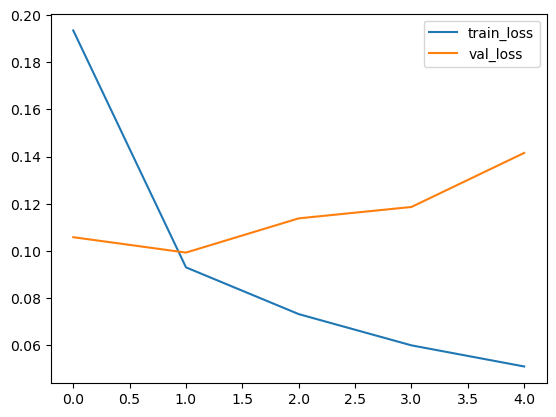

In [121]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [122]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

# Так как на выходе сигмоида (вероятности), превращаем их в 0 и 1
y_pred = (y_pred > 0.5).astype(int)

target_names = ['Нормальный', 'Оскорбление', 'Угроза', 'Неприрстойность']
print(classification_report(y_test, y_pred, target_names=target_names))

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step
                 precision    recall  f1-score   support

     Нормальный       0.95      0.97      0.96     42661
    Оскорбление       0.85      0.79      0.82      8733
         Угроза       0.88      0.74      0.80      1550
Неприрстойность       0.80      0.63      0.71       728

      micro avg       0.93      0.93      0.93     53672
      macro avg       0.87      0.78      0.82     53672
   weighted avg       0.93      0.93      0.93     53672
    samples avg       0.89      0.89      0.89     53672



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [123]:
def predict_toxicity(text):
    clean_text = full_preprocess(text) 
    print(f"Леммы: {clean_text}")
    
    seq = tokenizer.texts_to_sequences([clean_text]) 
    print(f"Индексы: {seq}")

    padded = pad_sequences(seq, maxlen=MAX_LEN)

    pred = model.predict(padded)[0]
    print(pred)
    
    results = dict(zip(target_names, pred))
    print(f"\nАнализ фразы: '{text}'")
    for label, prob in results.items():
        print(f"- {label}: {prob:.2%}")

In [124]:
predict_toxicity("Какашка")

Леммы: ['какашка']
Индексы: [[]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[0.83700645 0.13792513 0.01238794 0.01050165]

Анализ фразы: 'Какашка'
- Нормальный: 83.70%
- Оскорбление: 13.79%
- Угроза: 1.24%
- Неприрстойность: 1.05%


In [125]:
model.save('lstm_model.h5')